Aperçu du dataset :
  country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        Hydro         NaN   
4  GEODB0040534        100.0    34.641    69.7170        Hydro         NaN   

  other_fuel2  ...  estimated_generation_gwh_2013  \
0

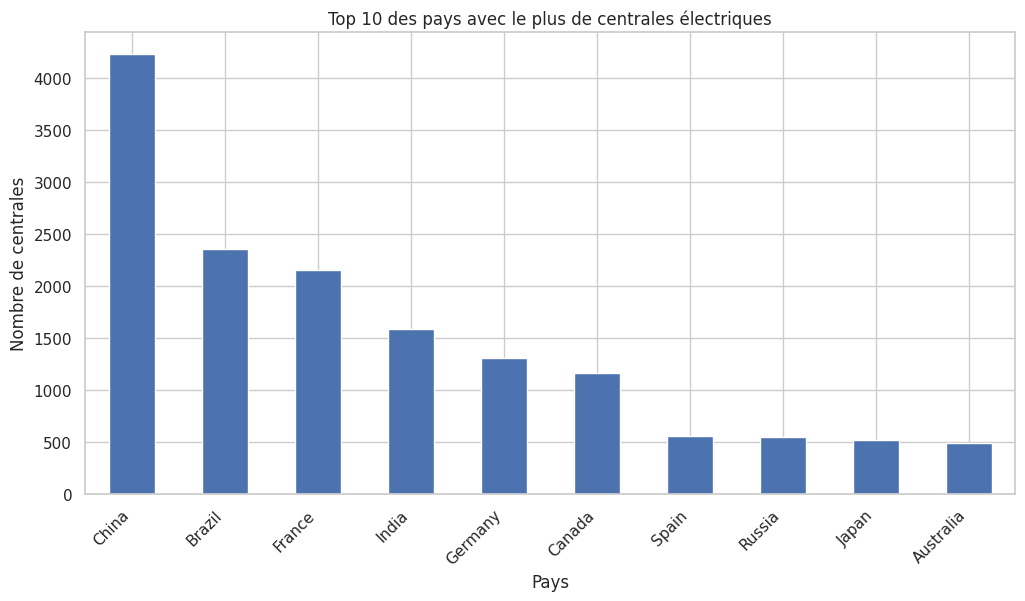


Répartition des centrales par type de combustible :
primary_fuel
Solar             5853
Hydro             4923
Wind              3215
Coal              1946
Gas               1924
Oil               1364
Biomass           1019
Waste              190
Nuclear            113
Geothermal         113
Other               27
Wave and Tidal       3
Petcoke              1
Name: count, dtype: int64


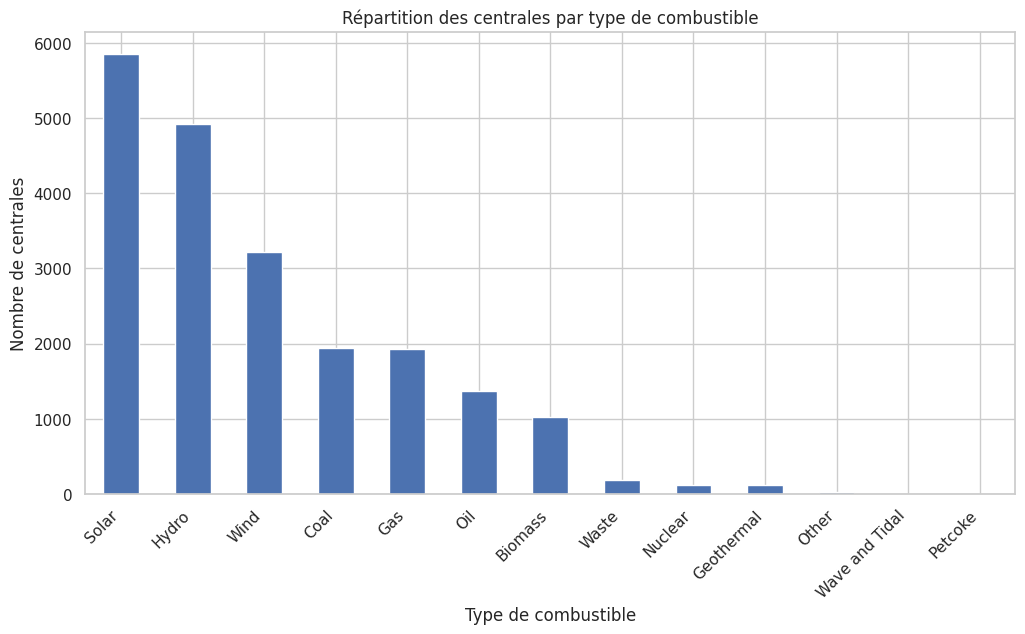


Analyse statistique de la capacité par type de combustible :
                    moyenne    mediane   ecart_type  nombre
primary_fuel                                               
Nuclear         2305.052566  2000.0000  1486.457111     113
Coal             832.394717   600.0000   895.580127    1946
Gas              405.247528   180.0000   617.117533    1924
Wave and Tidal   171.333333   240.0000   131.245317       3
Hydro            170.473036    25.0000   618.341046    4923
Oil              152.851066    11.3700   479.301330    1364
Other            112.609630    72.0000   176.627711      27
Geothermal        73.615487    34.0000   101.012332     113
Petcoke           62.977500    62.9775          NaN       1
Wind              39.776738    28.0000   114.613983    3215
Biomass           25.495745    12.0000    40.293906    1019
Solar             22.895037    10.0000    49.689239    5853
Waste             15.507637    10.0000    17.121209     190


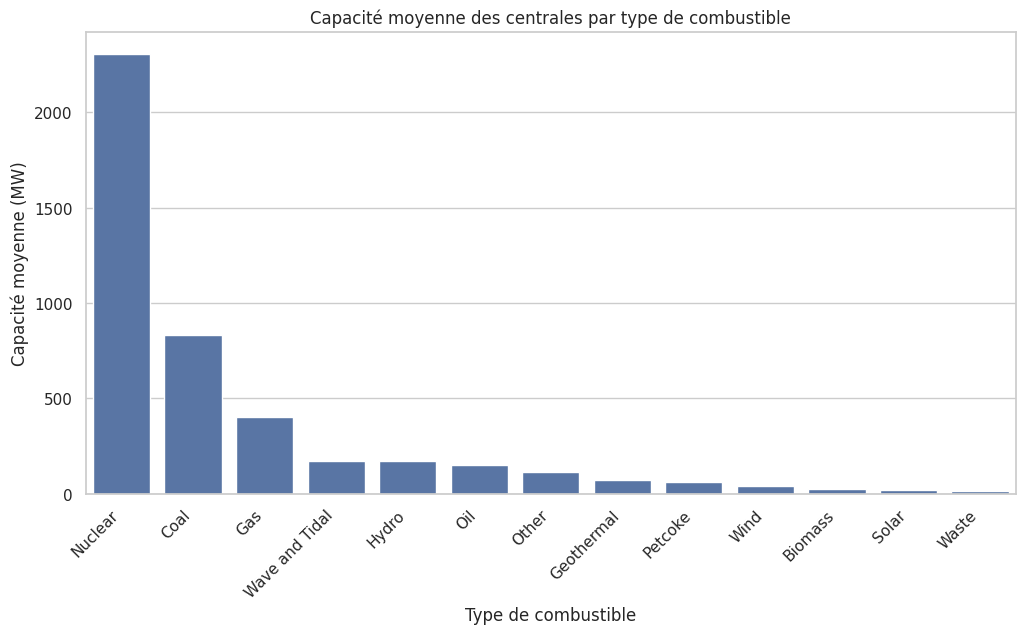


Types de combustibles utilisés dans le test ANOVA :
['Solar', 'Hydro', 'Wind', 'Coal', 'Gas', 'Oil', 'Biomass', 'Waste', 'Nuclear', 'Geothermal']

Test ANOVA sur la capacité moyenne selon le type de combustible :
Statistique F : 800.1794288483619
Valeur p : 0.0
Conclusion : Il existe une différence significative de capacité moyenne entre les types de combustibles.

Test t entre Solar et Coal :
Statistique t : -39.85304583171195
Valeur p : 1.5002504861900568e-254
Conclusion : La capacité moyenne des centrales solaires et au charbon est significativement différente.


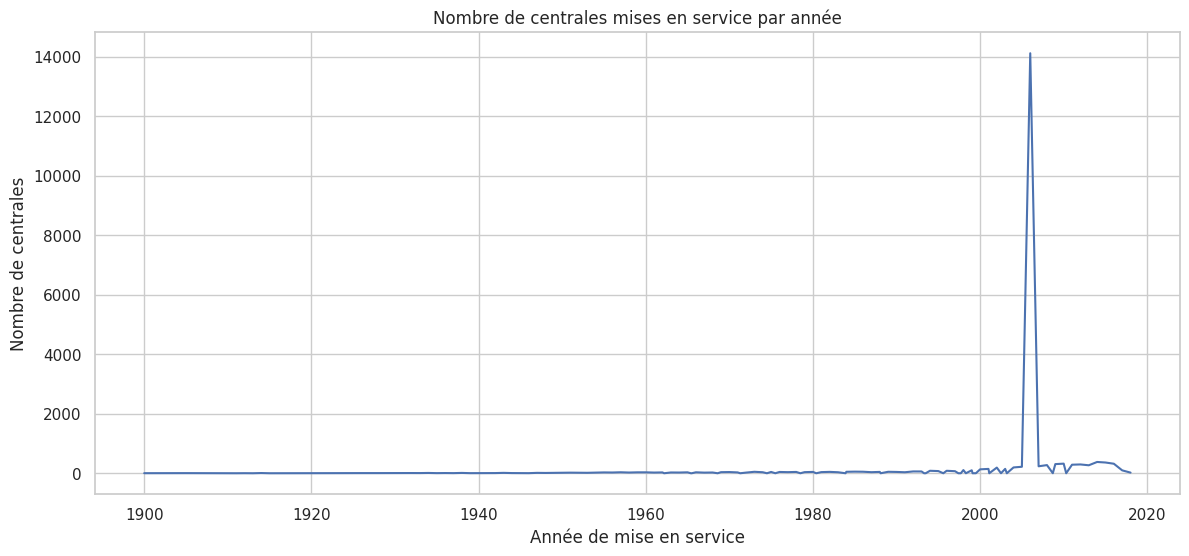


Aperçu des centrales par année :
commissioning_year
1900.0    3
1905.0    5
1908.0    2
1910.0    1
1911.0    1
dtype: int64


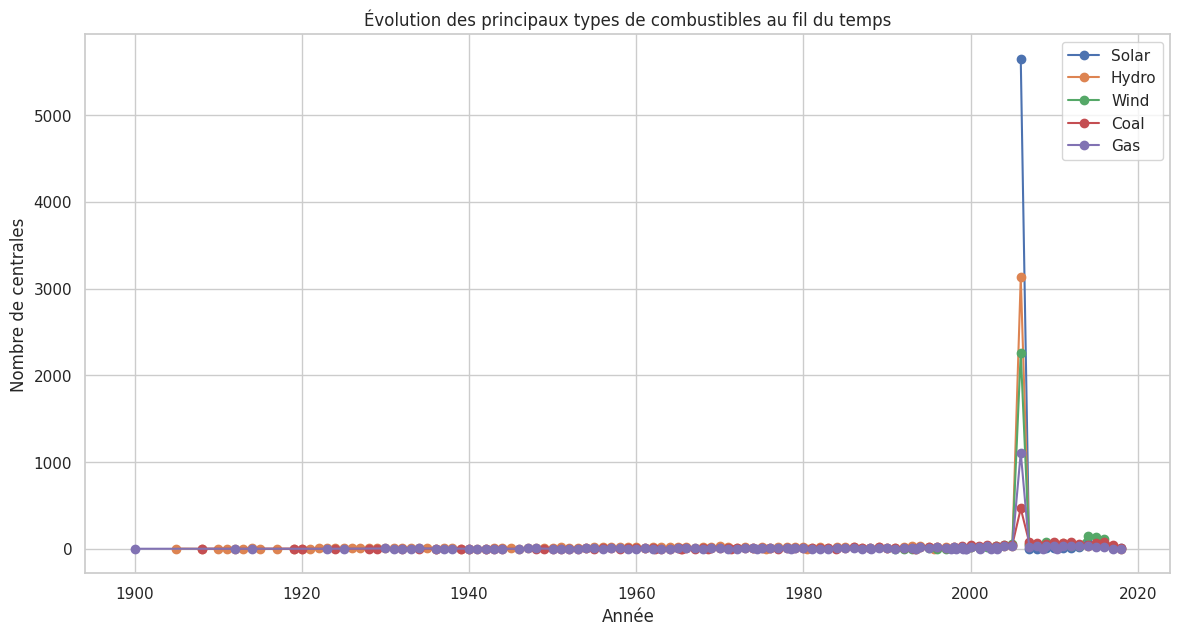

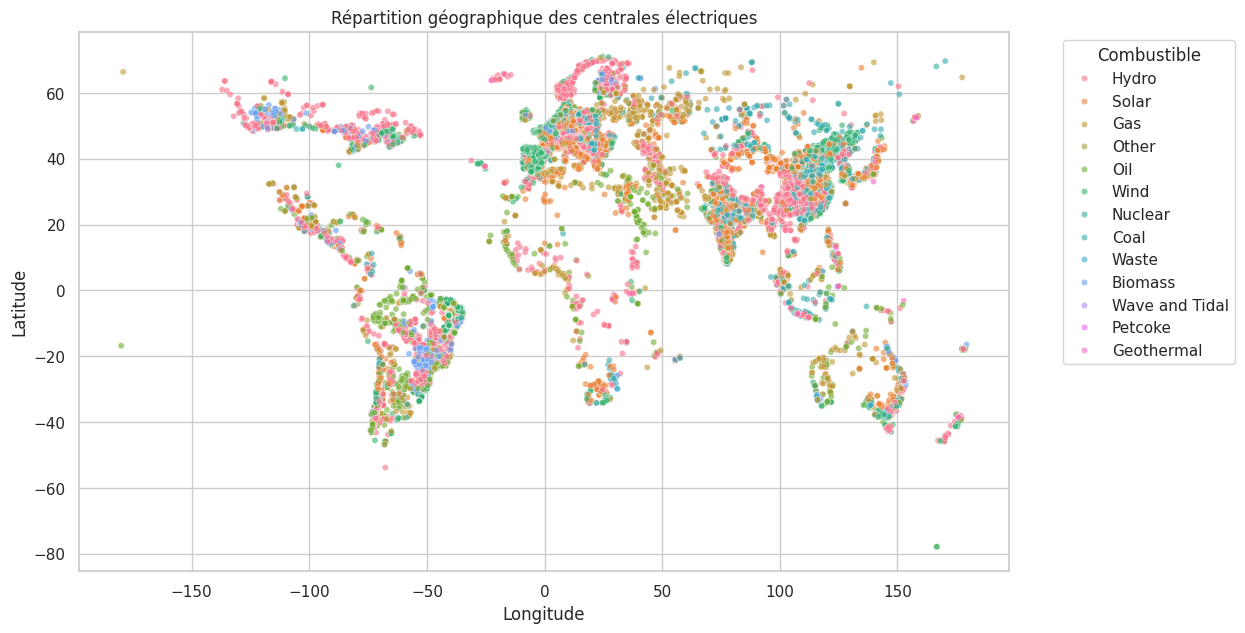

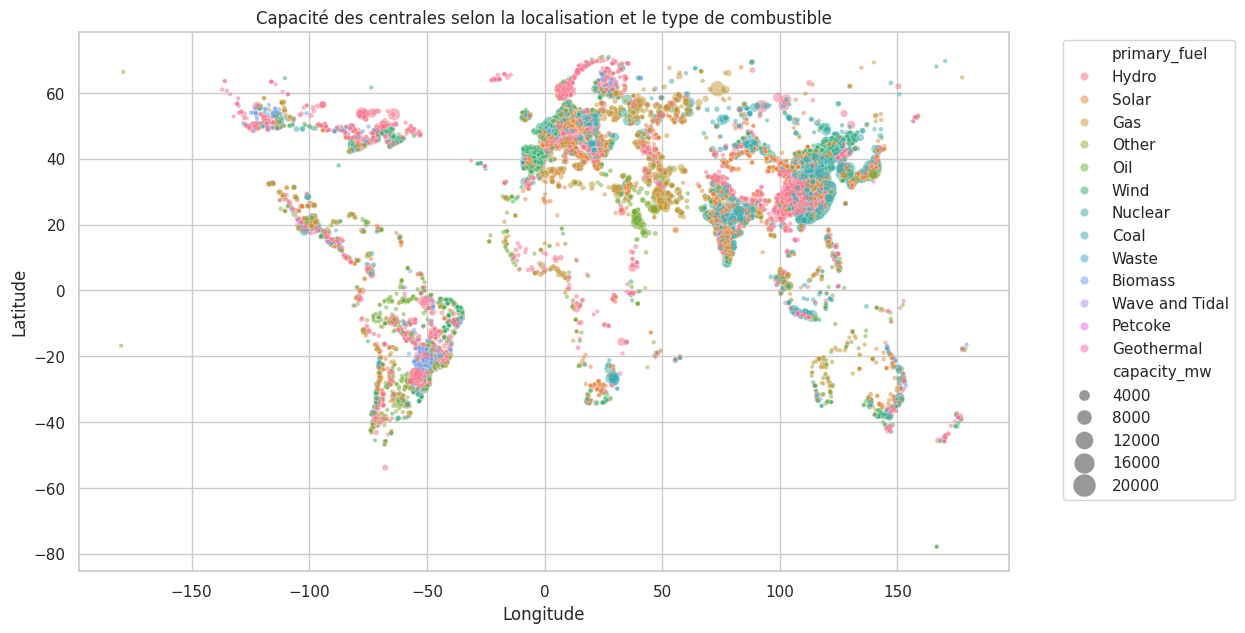


Matrice NumPy utilisée pour l'analyse :
[[  33.       32.322    65.119  2006.    ]
 [  10.       31.67     65.795  2006.    ]
 [  10.       31.623    65.792  2006.    ]
 [  66.       34.556    69.4787 2006.    ]
 [ 100.       34.641    69.717  2006.    ]]

Matrice de corrélation :
[[ 1.          0.03344766  0.16826858 -0.02731213]
 [ 0.03344766  1.          0.14422809 -0.06744933]
 [ 0.16826858  0.14422809  1.          0.02803805]
 [-0.02731213 -0.06744933  0.02803805  1.        ]]


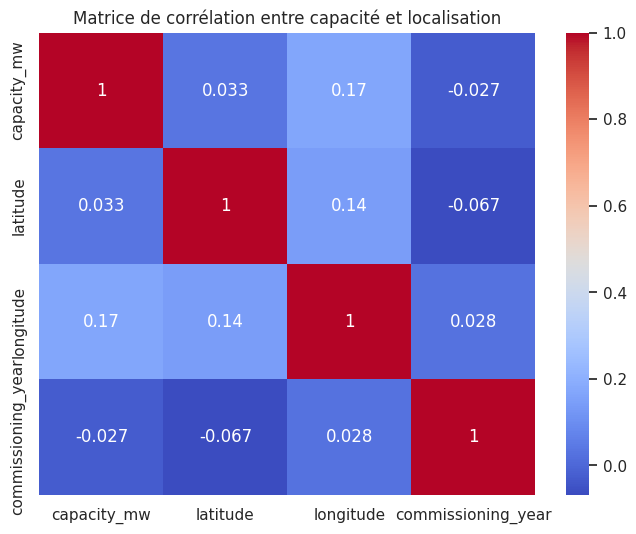


Valeurs propres :
[1.24242708 0.77540992 0.95069635 1.03146665]

Vecteurs propres :
[[ 0.54243109  0.48412286 -0.64425197  0.23734569]
 [ 0.50292476  0.45646867  0.62422457 -0.38606571]
 [ 0.6613029  -0.69108863  0.13308624  0.25954389]
 [-0.12455391  0.28223735  0.42139191  0.8527938 ]]

Interprétation :
Les valeurs propres indiquent l'importance de chaque direction principale dans les données.
Les vecteurs propres indiquent les directions principales de variation.
Dans ce contexte, ils peuvent aider à comprendre les relations entre capacité, localisation et année de mise en service.

Seuil du 90e percentile de capacité : 555.0
Nombre de centrales de grande capacité : 2070

Aperçu des centrales de grande capacité :
   country_long primary_fuel  capacity_mw
11      Albania        Hydro        600.0
27      Algeria          Gas        560.0
36      Algeria          Gas       1200.0
39      Algeria          Gas        600.0
47      Algeria          Gas        588.0


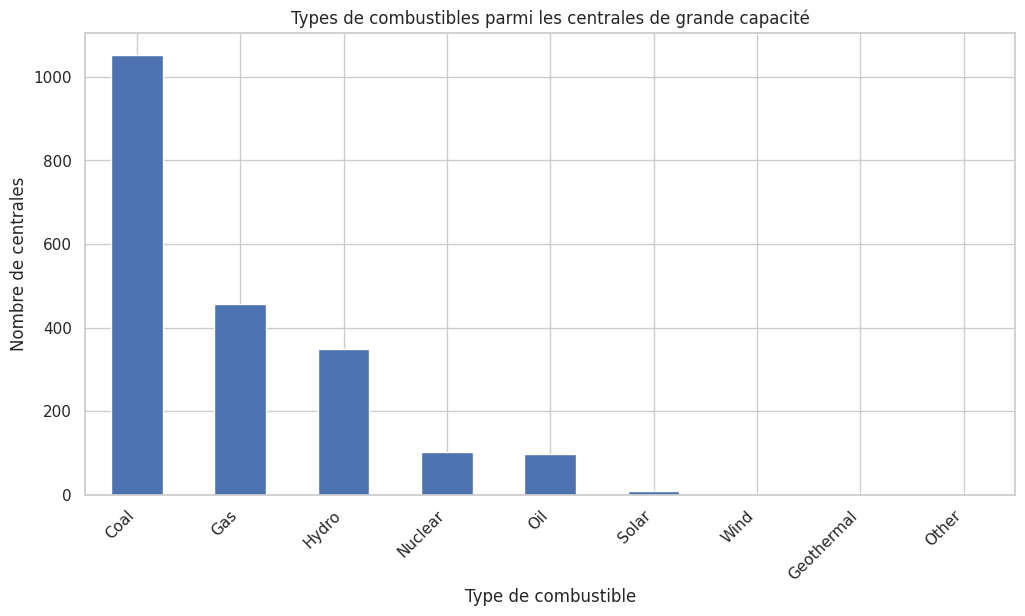


================ RAPPORT FINAL ================

1. Importation et nettoyage
Le dataset a été importé avec Pandas. Les valeurs manquantes numériques ont été remplacées par la médiane, et les valeurs catégorielles par 'Unknown'.

2. Analyse exploratoire
Nombre total de centrales analysées : 20691
Nombre total de pays : 138
Nombre de types de combustibles : 13

3. Statistiques de capacité
Capacité moyenne : 193.83 MW
Capacité médiane : 23.10 MW
Écart type de la capacité : 559.08 MW

4. Pays les plus représentés
country_long
China      4235
Brazil     2360
France     2155
India      1589
Germany    1309
Name: count, dtype: int64

5. Combustibles les plus utilisés
primary_fuel
Solar    5853
Hydro    4923
Wind     3215
Coal     1946
Gas      1924
Name: count, dtype: int64

6. Analyse statistique
Un test ANOVA a été utilisé pour vérifier si la capacité moyenne diffère selon les types de combustibles.

7. Analyse temporelle
L'année de mise en service a permis d'étudier l'évolution du nombre 

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, ttest_ind

sns.set(style="whitegrid")



file_path = "/content/global_power_plant_database.csv"

df = pd.read_csv(file_path)

print("Aperçu du dataset :")
print(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nColonnes disponibles :")
print(df.columns)

print("\nInformations générales :")
print(df.info())


df.columns = df.columns.str.strip()

print("\nNombre de doublons :", df.duplicated().sum())

df = df.drop_duplicates()

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


numeric_columns = [
    "capacity_mw",
    "latitude",
    "longitude",
    "commissioning_year",
    "generation_gwh_2013",
    "generation_gwh_2014",
    "generation_gwh_2015",
    "generation_gwh_2016",
    "generation_gwh_2017",
    "generation_gwh_2018",
    "generation_gwh_2019"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("\nValeurs manquantes après nettoyage :")
print(df.isnull().sum())



print("\nStatistiques descriptives des colonnes numériques :")
print(df.describe())

capacity_mean = np.mean(df["capacity_mw"])
capacity_median = np.median(df["capacity_mw"])
capacity_std = np.std(df["capacity_mw"])

print("\nStatistiques de la capacité des centrales :")
print("Moyenne :", capacity_mean)
print("Médiane :", capacity_median)
print("Écart type :", capacity_std)



plants_by_country = df["country_long"].value_counts().head(10)

print("\nTop 10 des pays avec le plus de centrales :")
print(plants_by_country)

plt.figure(figsize=(12, 6))
plants_by_country.plot(kind="bar")

plt.title("Top 10 des pays avec le plus de centrales électriques")
plt.xlabel("Pays")
plt.ylabel("Nombre de centrales")
plt.xticks(rotation=45, ha="right")
plt.show()


fuel_distribution = df["primary_fuel"].value_counts()

print("\nRépartition des centrales par type de combustible :")
print(fuel_distribution)

plt.figure(figsize=(12, 6))
fuel_distribution.plot(kind="bar")

plt.title("Répartition des centrales par type de combustible")
plt.xlabel("Type de combustible")
plt.ylabel("Nombre de centrales")
plt.xticks(rotation=45, ha="right")
plt.show()



capacity_by_fuel = df.groupby("primary_fuel")["capacity_mw"].agg(
    moyenne="mean",
    mediane="median",
    ecart_type="std",
    nombre="count"
).sort_values(by="moyenne", ascending=False)

print("\nAnalyse statistique de la capacité par type de combustible :")
print(capacity_by_fuel)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=capacity_by_fuel.index,
    y=capacity_by_fuel["moyenne"]
)

plt.title("Capacité moyenne des centrales par type de combustible")
plt.xlabel("Type de combustible")
plt.ylabel("Capacité moyenne (MW)")
plt.xticks(rotation=45, ha="right")
plt.show()


fuel_counts = df["primary_fuel"].value_counts()
valid_fuels = fuel_counts[fuel_counts > 30].index

groups = []

for fuel in valid_fuels:
    group = df[df["primary_fuel"] == fuel]["capacity_mw"].dropna()
    groups.append(group)

print("\nTypes de combustibles utilisés dans le test ANOVA :")
print(list(valid_fuels))

if len(groups) >= 2:
    f_stat, p_value = f_oneway(*groups)

    print("\nTest ANOVA sur la capacité moyenne selon le type de combustible :")
    print("Statistique F :", f_stat)
    print("Valeur p :", p_value)

    if p_value < 0.05:
        print("Conclusion : Il existe une différence significative de capacité moyenne entre les types de combustibles.")
    else:
        print("Conclusion : Il n'existe pas de différence significative de capacité moyenne entre les types de combustibles.")



if "Solar" in df["primary_fuel"].unique() and "Coal" in df["primary_fuel"].unique():
    solar_capacity = df[df["primary_fuel"] == "Solar"]["capacity_mw"]
    coal_capacity = df[df["primary_fuel"] == "Coal"]["capacity_mw"]

    t_stat, p_value = ttest_ind(solar_capacity, coal_capacity, equal_var=False)

    print("\nTest t entre Solar et Coal :")
    print("Statistique t :", t_stat)
    print("Valeur p :", p_value)

    if p_value < 0.05:
        print("Conclusion : La capacité moyenne des centrales solaires et au charbon est significativement différente.")
    else:
        print("Conclusion : Pas de différence significative entre les deux moyennes.")


if "commissioning_year" in df.columns:
    df_time = df[
        (df["commissioning_year"] >= 1900) &
        (df["commissioning_year"] <= 2023)
    ]

    plants_by_year = df_time.groupby("commissioning_year").size()

    plt.figure(figsize=(14, 6))
    plants_by_year.plot()

    plt.title("Nombre de centrales mises en service par année")
    plt.xlabel("Année de mise en service")
    plt.ylabel("Nombre de centrales")
    plt.grid(True)
    plt.show()

    print("\nAperçu des centrales par année :")
    print(plants_by_year.head())



if "commissioning_year" in df.columns:
    fuel_time = df_time.groupby(["commissioning_year", "primary_fuel"]).size().reset_index(name="count")

    top_fuels = df["primary_fuel"].value_counts().head(5).index

    plt.figure(figsize=(14, 7))

    for fuel in top_fuels:
        fuel_data = fuel_time[fuel_time["primary_fuel"] == fuel]
        plt.plot(
            fuel_data["commissioning_year"],
            fuel_data["count"],
            marker="o",
            label=fuel
        )

    plt.title("Évolution des principaux types de combustibles au fil du temps")
    plt.xlabel("Année")
    plt.ylabel("Nombre de centrales")
    plt.legend()
    plt.grid(True)
    plt.show()



if "latitude" in df.columns and "longitude" in df.columns:
    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=df,
        x="longitude",
        y="latitude",
        hue="primary_fuel",
        alpha=0.6,
        s=20
    )

    plt.title("Répartition géographique des centrales électriques")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title="Combustible", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()



plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    size="capacity_mw",
    hue="primary_fuel",
    alpha=0.5,
    sizes=(10, 300)
)

plt.title("Capacité des centrales selon la localisation et le type de combustible")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



matrix_columns = ["capacity_mw", "latitude", "longitude"]

if "commissioning_year" in df.columns:
    matrix_columns.append("commissioning_year")

matrix_data = df[matrix_columns].dropna()

matrix_np = matrix_data.to_numpy()

print("\nMatrice NumPy utilisée pour l'analyse :")
print(matrix_np[:5])

correlation_matrix = np.corrcoef(matrix_np, rowvar=False)

print("\nMatrice de corrélation :")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    xticklabels=matrix_columns,
    yticklabels=matrix_columns,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation entre capacité et localisation")
plt.show()



eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

print("\nValeurs propres :")
print(eigenvalues)

print("\nVecteurs propres :")
print(eigenvectors)

print("\nInterprétation :")
print("Les valeurs propres indiquent l'importance de chaque direction principale dans les données.")
print("Les vecteurs propres indiquent les directions principales de variation.")
print("Dans ce contexte, ils peuvent aider à comprendre les relations entre capacité, localisation et année de mise en service.")



large_capacity_threshold = np.percentile(df["capacity_mw"], 90)

large_plants = df[df["capacity_mw"] >= large_capacity_threshold]

print("\nSeuil du 90e percentile de capacité :", large_capacity_threshold)
print("Nombre de centrales de grande capacité :", large_plants.shape[0])

print("\nAperçu des centrales de grande capacité :")
print(large_plants[["country_long", "primary_fuel", "capacity_mw"]].head())



large_fuel_distribution = large_plants["primary_fuel"].value_counts()

plt.figure(figsize=(12, 6))
large_fuel_distribution.plot(kind="bar")

plt.title("Types de combustibles parmi les centrales de grande capacité")
plt.xlabel("Type de combustible")
plt.ylabel("Nombre de centrales")
plt.xticks(rotation=45, ha="right")
plt.show()



print("\n================ RAPPORT FINAL ================")

print("\n1. Importation et nettoyage")
print("Le dataset a été importé avec Pandas. Les valeurs manquantes numériques ont été remplacées par la médiane, et les valeurs catégorielles par 'Unknown'.")

print("\n2. Analyse exploratoire")
print(f"Nombre total de centrales analysées : {df.shape[0]}")
print(f"Nombre total de pays : {df['country_long'].nunique()}")
print(f"Nombre de types de combustibles : {df['primary_fuel'].nunique()}")

print("\n3. Statistiques de capacité")
print(f"Capacité moyenne : {capacity_mean:.2f} MW")
print(f"Capacité médiane : {capacity_median:.2f} MW")
print(f"Écart type de la capacité : {capacity_std:.2f} MW")

print("\n4. Pays les plus représentés")
print(plants_by_country.head(5))

print("\n5. Combustibles les plus utilisés")
print(fuel_distribution.head(5))

print("\n6. Analyse statistique")
print("Un test ANOVA a été utilisé pour vérifier si la capacité moyenne diffère selon les types de combustibles.")

print("\n7. Analyse temporelle")
print("L'année de mise en service a permis d'étudier l'évolution du nombre de centrales au fil du temps.")

print("\n8. Opérations matricielles")
print("Une matrice de corrélation a été construite avec NumPy afin d'étudier les relations entre capacité, latitude, longitude et année.")
print("Les valeurs propres et vecteurs propres permettent d'identifier les directions principales de variation dans les données.")

print("\n9. Conclusion générale")
print("Cette analyse montre que NumPy, Pandas, Matplotlib et Seaborn peuvent être combinés pour nettoyer, analyser et visualiser un dataset réel complexe.")